In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
s_data = pd.read_csv('raw_data/healthcare-dataset-stroke-data.csv')

In [3]:
s_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [4]:
s_data.head(20)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [5]:
s_data.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [6]:
s_data['id'].duplicated().sum()

np.int64(0)

In [7]:
s_data['gender'].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [8]:
s_data['hypertension'].unique()

array([0, 1])

In [9]:
s_data['heart_disease'].unique()

array([1, 0])

In [10]:
s_data['ever_married'].unique()

array(['Yes', 'No'], dtype=object)

In [11]:
s_data['work_type'].unique()

array(['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'],
      dtype=object)

In [12]:
s_data['Residence_type'].unique()

array(['Urban', 'Rural'], dtype=object)

In [13]:
s_data['smoking_status'].unique()

array(['formerly smoked', 'never smoked', 'smokes', 'Unknown'],
      dtype=object)

In [14]:
s_data['stroke'].unique()

array([1, 0])

In [15]:
s_data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,5110.0,36517.829354,21161.721625,67.00,17741.250,36932.000,54682.00,72940.00
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
hypertension,5110.0,0.097456,0.296607,0.00,0.000,0.000,0.00,1.00
heart_disease,5110.0,0.054012,0.226063,0.00,0.000,0.000,0.00,1.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60
stroke,5110.0,0.048728,0.215320,0.00,0.000,0.000,0.00,1.00


In [16]:
stroke_counts = s_data["stroke"].value_counts()
stroke_percentages = s_data["stroke"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "count": stroke_counts,
    "percentage": stroke_percentages
})

target_summary

,count,percentage
stroke,,
0,4861,95.127202
1,249,4.872798


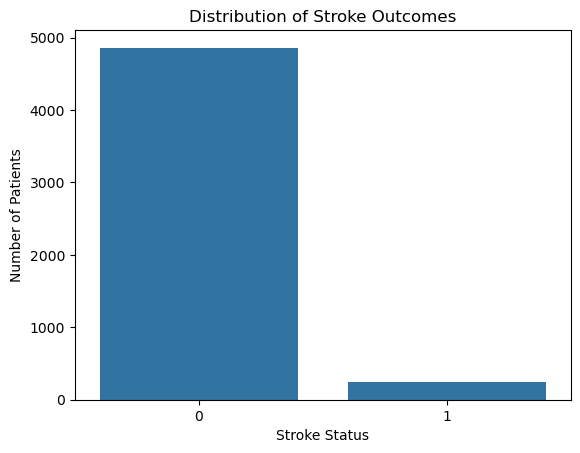

In [17]:
sns.countplot(data=s_data, x="stroke")
plt.title("Distribution of Stroke Outcomes")
plt.xlabel("Stroke Status")
plt.ylabel("Number of Patients")
plt.show()

In [18]:
s_data["bmi_missing"] = s_data["bmi"].isna().astype(int)

In [19]:
s_data.head(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_missing
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,0
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,0
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,0
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,0


In [20]:
s_data.groupby("stroke")["bmi_missing"].mean() * 100

stroke
0     3.312076
1    16.064257
Name: bmi_missing, dtype: float64

BMI is missing for about 3.3% of non-stroke records and 16.1% of stroke records. 
Therefore, deleting all rows with missing BMI could disproportionately remove stroke cases and bias the analysis.

In [21]:
numerical_columns = [
    "age",
    "avg_glucose_level",
    "bmi"
]

s_data[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,5110.0,43.226614,22.612647,0.08,25.000,45.000,61.00,82.00
avg_glucose_level,5110.0,106.147677,45.283560,55.12,77.245,91.885,114.09,271.74
bmi,4909.0,28.893237,7.854067,10.30,23.500,28.100,33.10,97.60


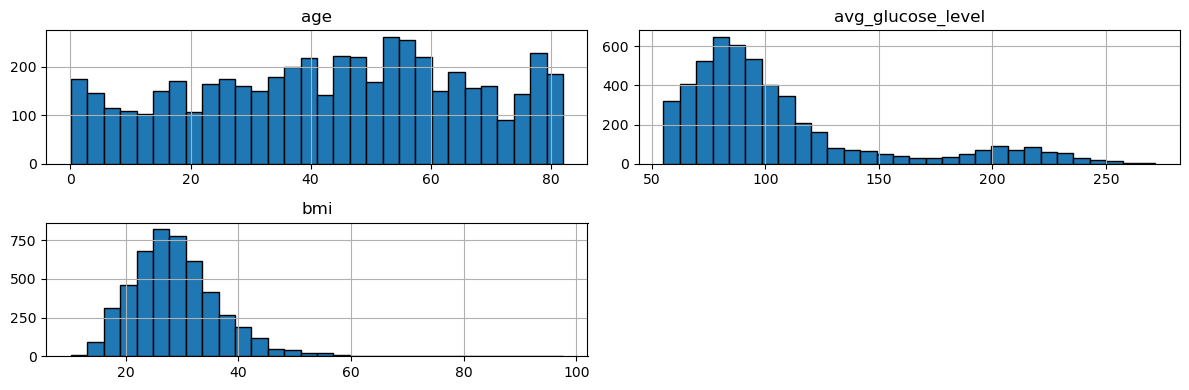

In [22]:
s_data[numerical_columns].hist(
    bins=30,
    figsize=(12, 4),
    edgecolor="black"
)

plt.tight_layout()
plt.show()

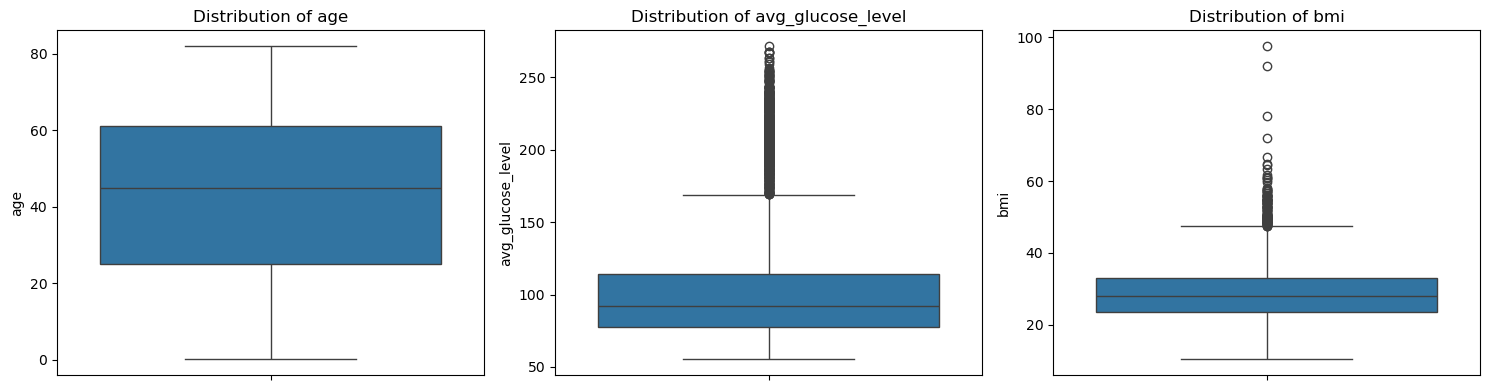

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for column, ax in zip(numerical_columns, axes):
    sns.boxplot(data=s_data, y=column, ax=ax)
    ax.set_title(f"Distribution of {column}")

plt.tight_layout()
plt.show()

In [24]:
s_data.groupby("stroke")[numerical_columns].agg(
    ["count", "mean", "median", "std"]
).T

stroke                              0           1
age               count   4861.000000  249.000000
                  mean      41.971545   67.728193
                  median    43.000000   71.000000
                  std       22.291940   12.727419
avg_glucose_level count   4861.000000  249.000000
                  mean     104.795513  132.544739
                  median    91.470000  105.220000
                  std       43.846069   61.921056
bmi               count   4700.000000  209.000000
                  mean      28.823064   30.471292
                  median    28.000000   29.700000
                  std        7.908287    6.329452

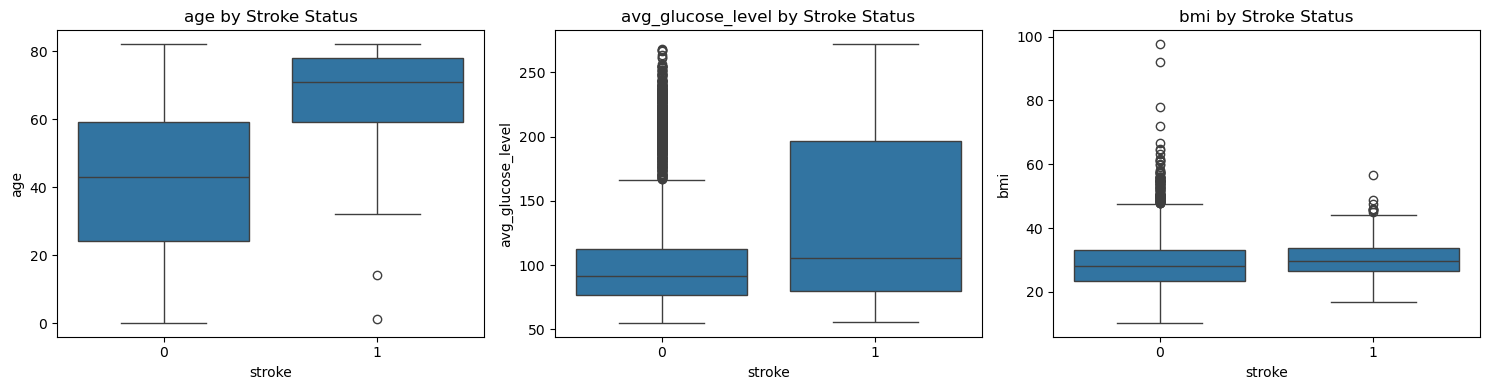

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for column, ax in zip(numerical_columns, axes):
    sns.boxplot(data=s_data, x="stroke", y=column, ax=ax)
    ax.set_title(f"{column} by Stroke Status")

plt.tight_layout()
plt.show()

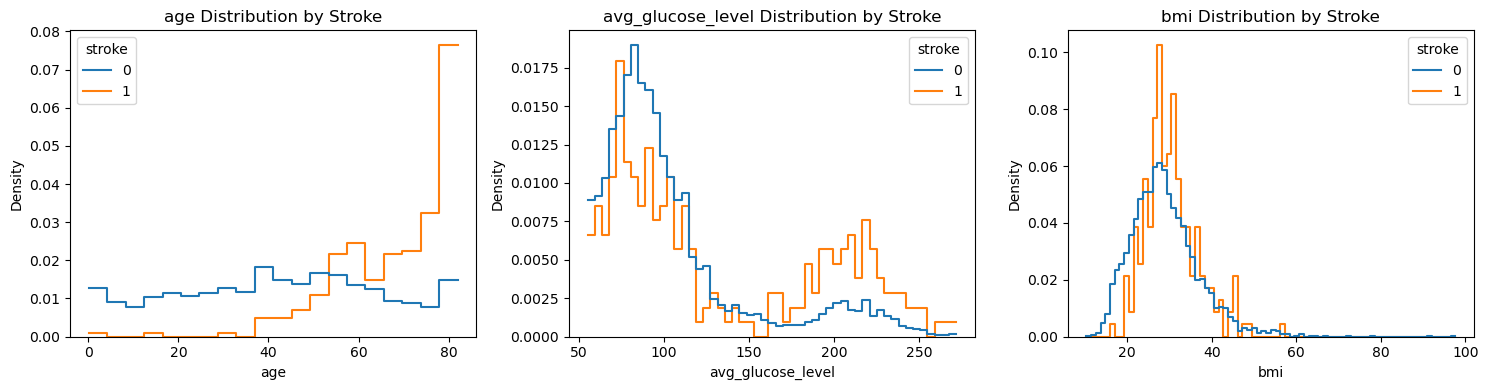

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for column, ax in zip(numerical_columns, axes):
    sns.histplot(
        data=s_data,
        x=column,
        hue="stroke",
        stat="density",
        common_norm=False,
        element="step",
        fill=False,
        ax=ax
    )
    ax.set_title(f"{column} Distribution by Stroke")

plt.tight_layout()
plt.show()

In [27]:
categorical_analysis_columns = [
    "gender",
    "hypertension",
    "heart_disease",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

In [28]:
for column in categorical_analysis_columns:
    print(s_data[column].value_counts(dropna=False))
    print("-------")

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64
-------
hypertension
0    4612
1     498
Name: count, dtype: int64
-------
heart_disease
0    4834
1     276
Name: count, dtype: int64
-------
ever_married
Yes    3353
No     1757
Name: count, dtype: int64
-------
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64
-------
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64
-------
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64
-------


In [29]:
for column in categorical_analysis_columns:
    stroke_rate = (
        s_data.groupby(column, observed=False)["stroke"]
          .agg(["count", "sum", "mean"])
          .rename(columns={
              "sum": "stroke_cases",
              "mean": "stroke_rate"
          })
    )

    stroke_rate["stroke_rate"] *= 100

    print(f"\nStroke results by {column}")
    print(stroke_rate.sort_values("stroke_rate", ascending=False))


Stroke results by gender
        count  stroke_cases  stroke_rate
gender                                  
Male     2115           108     5.106383
Female   2994           141     4.709419
Other       1             0     0.000000

Stroke results by hypertension
              count  stroke_cases  stroke_rate
hypertension                                  
1               498            66    13.253012
0              4612           183     3.967910

Stroke results by heart_disease
               count  stroke_cases  stroke_rate
heart_disease                                  
1                276            47    17.028986
0               4834           202     4.178734

Stroke results by ever_married
              count  stroke_cases  stroke_rate
ever_married                                  
Yes            3353           220     6.561288
No             1757            29     1.650541

Stroke results by work_type
               count  stroke_cases  stroke_rate
work_type                  

***Stroke rate within each category

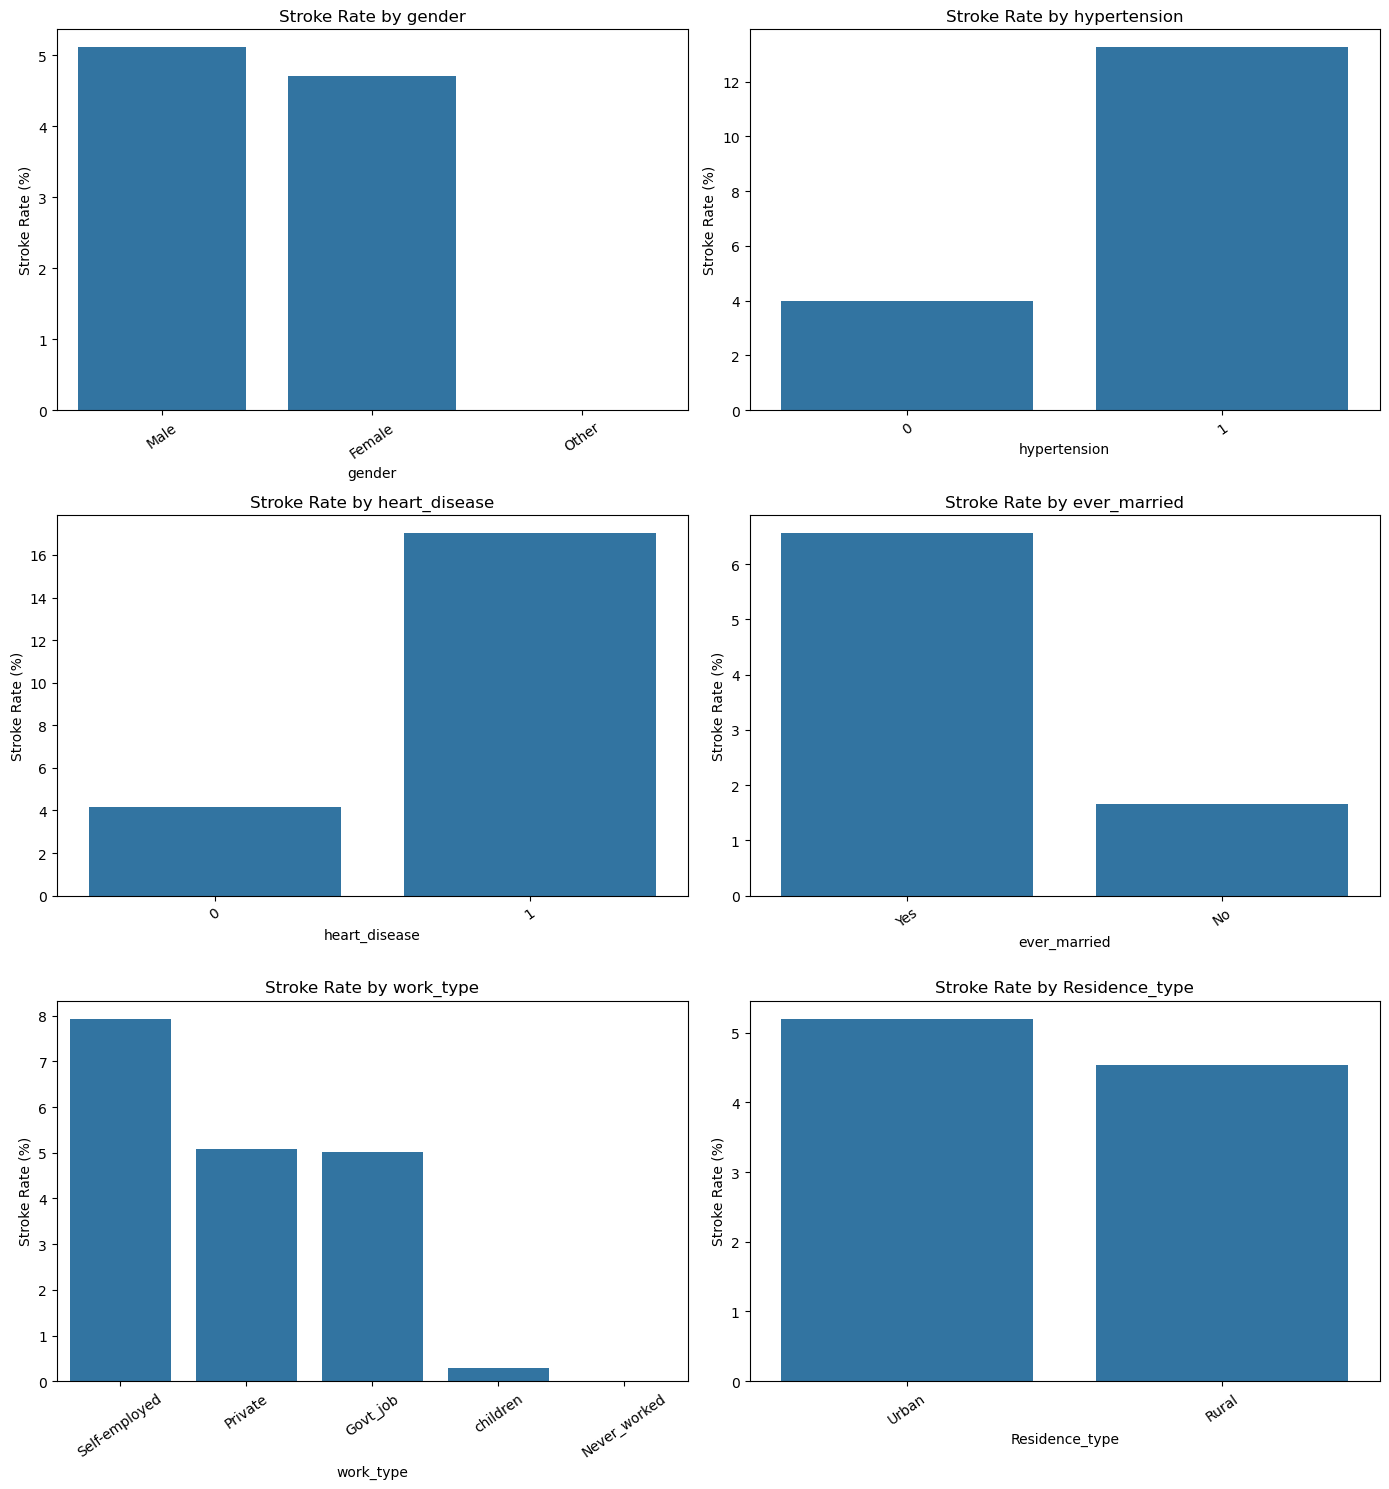

In [32]:
#Visualizing categorical stroke rates
fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()

plot_columns = [
    "gender",
    "hypertension",
    "heart_disease",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status"
]

for column, ax in zip(plot_columns, axes):
    rates = (
        s_data.groupby(column, observed=False)["stroke"]
          .mean()
          .mul(100)
          .sort_values(ascending=False)
          .reset_index()
    )

    sns.barplot(
        data=rates,
        x=column,
        y="stroke",
        ax=ax
    )

    ax.set_title(f"Stroke Rate by {column}")
    ax.set_ylabel("Stroke Rate (%)")
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

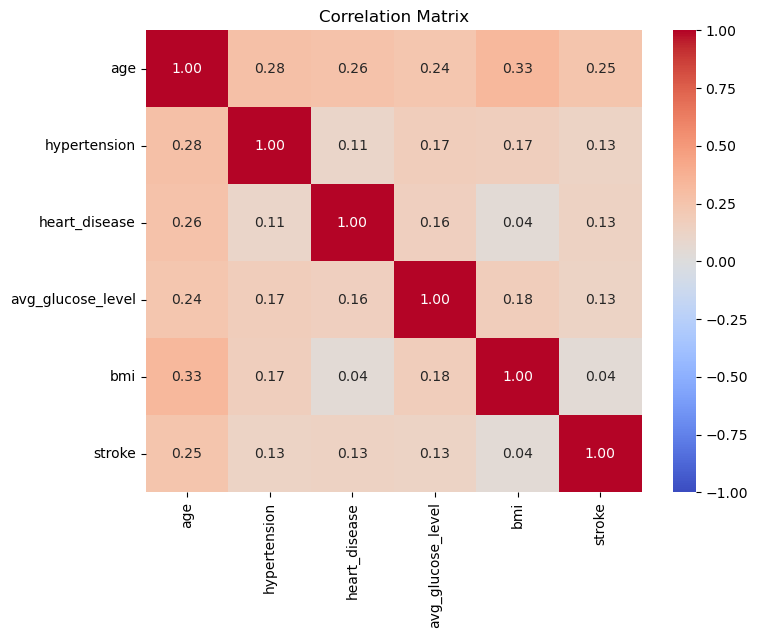

In [33]:
correlation_columns = [
    "age",
    "hypertension",
    "heart_disease",
    "avg_glucose_level",
    "bmi",
    "stroke"
]

correlation_matrix = s_data[correlation_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix")
plt.show()